# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.


## Dataset
Use the **Boston Housing dataset**.
    
    from sklearn.datasets import load_boston

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = boston.frame.apply(pd.to_numeric)
print("Shape:", df.shape)
df.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 1. Data Preparation

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Train size: 354
Test size:  152


In [6]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
204,0.02009,95.0,2.68,0,0.4161,8.034,31.9,5.1180,4,224.0,14.7,390.55,2.88
370,6.53876,0.0,18.10,1,0.6310,7.016,97.5,1.2024,24,666.0,20.2,392.05,2.96
485,3.67367,0.0,18.10,0,0.5830,6.312,51.9,3.9917,24,666.0,20.2,388.62,10.58
86,0.05188,0.0,4.49,0,0.4490,6.015,45.1,4.4272,3,247.0,18.5,395.99,12.86
241,0.10612,30.0,4.93,0,0.4280,6.095,65.1,6.3361,6,300.0,16.6,394.62,12.40


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
test_predictions = model.predict(X_test)

In [9]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)

print(f"MAE:  {MAE:.4f}")
print(f"MSE:  {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")

MAE:  3.8357
MSE:  28.5476
RMSE: 5.3430


In [10]:
pd.Series(model.coef_, index=X.columns)

CRIM       -0.088505
ZN          0.050293
INDUS       0.020348
CHAS        3.754271
NOX       -17.748371
RM          3.247765
AGE         0.012001
DIS        -1.409161
RAD         0.263881
TAX        -0.010344
PTRATIO    -0.951781
B           0.006116
LSTAT      -0.597133
dtype: float64

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE


In [11]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)
poly_features = polynomial_converter.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [12]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
test_predictions_poly = poly_model.predict(X_test_poly)

MAE_poly = mean_absolute_error(y_test_poly, test_predictions_poly)
MSE_poly = mean_squared_error(y_test_poly, test_predictions_poly)
RMSE_poly = np.sqrt(MSE_poly)

print(f"MAE:  {MAE_poly:.4f}")
print(f"MSE:  {MSE_poly:.4f}")
print(f"RMSE: {RMSE_poly:.4f}")

MAE:  2.7017
MSE:  14.5331
RMSE: 3.8122


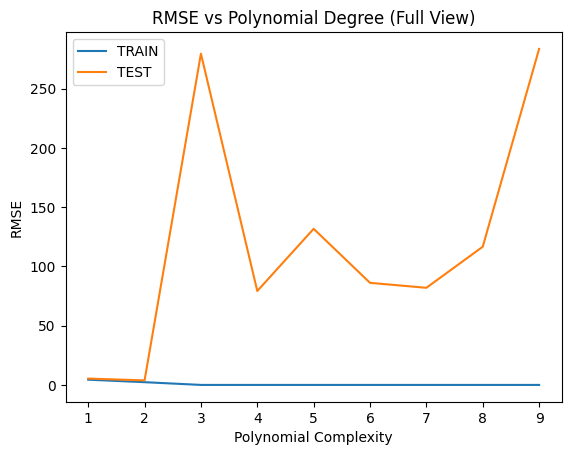

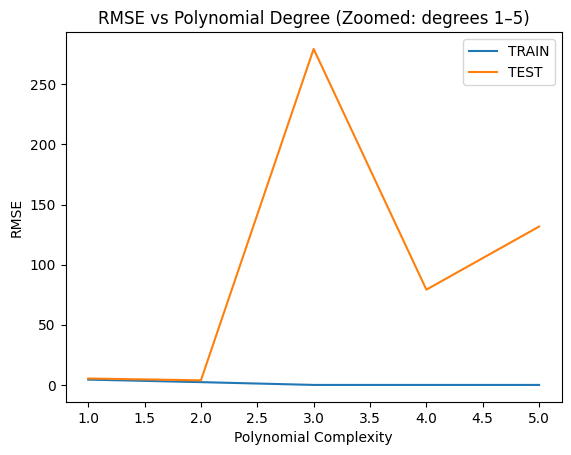

In [14]:
# TRAINING ERROR PER DEGREE
train_rmse_errors = []
# TEST ERROR PER DEGREE
test_rmse_errors = []

for d in range(1, 10):

    # CREATE POLY DATA SET FOR DEGREE "d"
    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features_d = polynomial_converter.fit_transform(X)

    # SPLIT THIS NEW POLY DATA SET
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(poly_features_d, y, test_size=0.3, random_state=101)

    # TRAIN ON THIS NEW POLY SET
    model_d = LinearRegression()
    model_d.fit(X_train_d, y_train_d)

    # PREDICT ON BOTH TRAIN AND TEST
    train_pred_d = model_d.predict(X_train_d)
    test_pred_d  = model_d.predict(X_test_d)

    # Errors on Train Set
    train_RMSE = np.sqrt(mean_squared_error(y_train_d, train_pred_d))
    # Errors on Test Set
    test_RMSE  = np.sqrt(mean_squared_error(y_test_d,  test_pred_d))

    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

plt.plot(range(1, 10), train_rmse_errors, label='TRAIN')
plt.plot(range(1, 10), test_rmse_errors,  label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.title("RMSE vs Polynomial Degree (Full View)")
plt.legend()
plt.show()

plt.plot(range(1, 6), train_rmse_errors[:5], label='TRAIN')
plt.plot(range(1, 6), test_rmse_errors[:5],  label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.title("RMSE vs Polynomial Degree (Zoomed: degrees 1–5)")
plt.legend()
plt.show()

### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision


In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (degree=2)'],
    'MAE':  [round(MAE, 4),      round(MAE_poly, 4)],
    'MSE':  [round(MSE, 4),      round(MSE_poly, 4)],
    'RMSE': [round(RMSE, 4),     round(RMSE_poly, 4)]
})
results

,Model,MAE,MSE,RMSE
0,Linear Regression,3.8357,28.5476,5.3430
1,Polynomial Regression (degree=2),2.7017,14.5331,3.8122


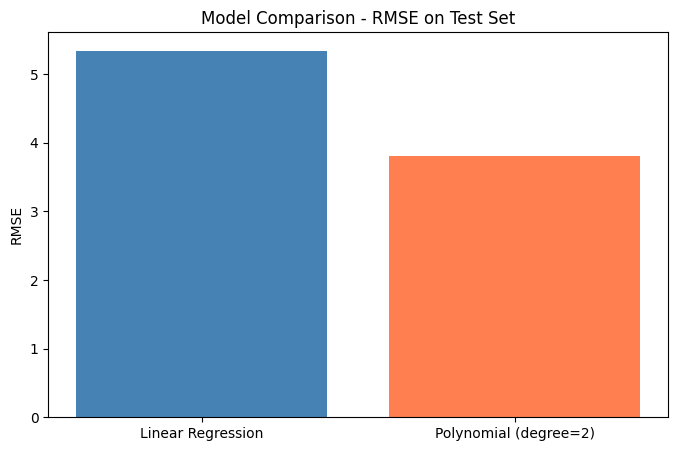

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(['Linear Regression', 'Polynomial (degree=2)'], [RMSE, RMSE_poly], color=['steelblue', 'coral'])
plt.ylabel('RMSE')
plt.title('Model Comparison - RMSE on Test Set')
plt.show()

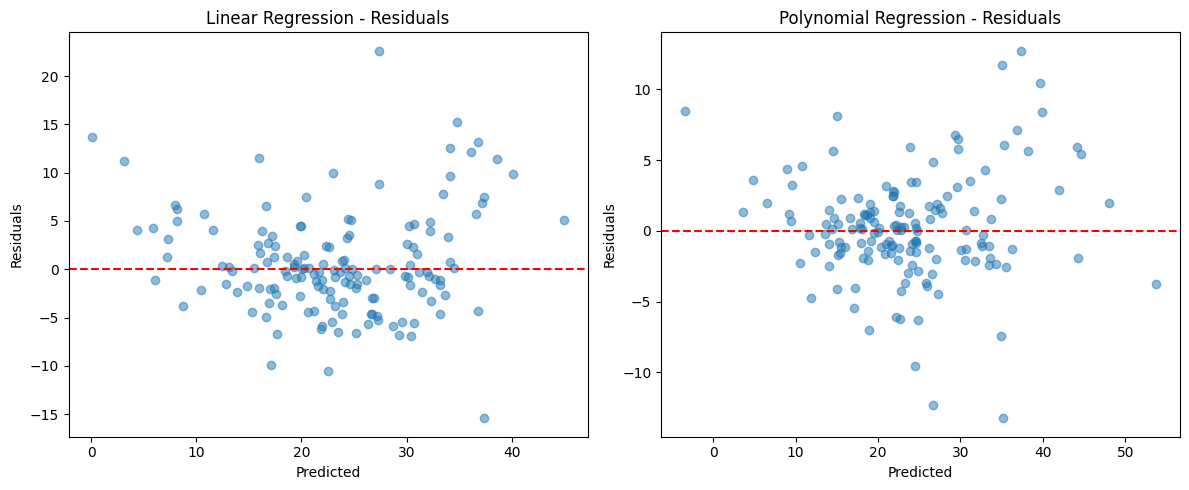

In [17]:
residuals_linear = y_test - test_predictions
residuals_poly   = y_test_poly - test_predictions_poly

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(test_predictions, residuals_linear, alpha=0.5)
axes[0].axhline(0, linestyle='--', color='red')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Linear Regression - Residuals")

axes[1].scatter(test_predictions_poly, residuals_poly, alpha=0.5)
axes[1].axhline(0, linestyle='--', color='red')
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Polynomial Regression - Residuals")

plt.tight_layout()
plt.show()

In [18]:
# Based on the chart, degree=2 provides the best balance — low test error without overfitting
final_poly_converter = PolynomialFeatures(degree=2, include_bias=False)

final_model = LinearRegression()
final_model.fit(final_poly_converter.fit_transform(X), y)

print("Final model trained on full dataset with degree=2 polynomial features.")
print(f"Number of features after transformation: {final_poly_converter.fit_transform(X).shape[1]}")

Final model trained on full dataset with degree=2 polynomial features.
Number of features after transformation: 104


## Conclusion

### Model Comparison Results

| Model | MAE | MSE | RMSE |
|---|---|---|---|
| Linear Regression | 3.8357 | 28.5476 | 5.3430 |
| Polynomial Regression (degree=2) | 2.7017 | 14.5331 | 3.8122 |

**Polynomial Regression (degree=2) is the better model** — it outperforms Linear Regression on all three metrics with a ~29% reduction in RMSE (5.34 → 3.81).

---

### Interpreting the Linear Model's Learned Equation

The Linear Regression equation is:

**MEDV = 3.75·CHAS − 17.75·NOX + 3.25·RM − 1.41·DIS − 0.95·PTRATIO − 0.60·LSTAT + ...**

Key coefficient interpretations:
- **RM (+3.25)**: Each additional room increases house price by ~$3,250 → more rooms = higher value ✅
- **LSTAT (−0.60)**: Higher % of lower-status population decreases price → poorer neighborhoods = lower value ✅
- **NOX (−17.75)**: Higher nitric oxide concentration (pollution) strongly decreases price ✅
- **CHAS (+3.75)**: Being next to the Charles River adds ~$3,750 in value ✅
- **PTRATIO (−0.95)**: Higher pupil-teacher ratio (worse schools) decreases price ✅

---

### Why Polynomial is Better

1. **Non-linear relationships**: Features like `LSTAT` and `RM` have curved relationships with price — polynomial features capture this.
2. **Interaction terms**: Degree-2 adds cross-terms (e.g., `LSTAT × RM`) that capture combined feature effects.
3. **Degree selection**: The RMSE vs Degree plot confirms degree=2 is optimal — higher degrees overfit (train error drops but test error rises).